In [1]:
PATH = "/projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG"

### Behaviour Check


In [4]:
import pandas as pd
import os
import numpy as np

loc = []
identity = [] 
beh_data_overall = []
for sub in [0,1,2,3,4,5]:
    folder_name = f"sub-{sub:04d}"
    sub_folder = os.path.join(PATH, "beh", folder_name)
    files = os.listdir(sub_folder)

    csvs = [x for x in files if ".csv" in x]
    beh_data = []

    for csv in csvs:
        csv_file =os.path.join(sub_folder, csv)
        beh_data.append(pd.read_csv(csv_file))
        
    beh_data = pd.concat(beh_data).reset_index(drop=True)

    # substitute all None with np.nan
    beh_data = beh_data.replace(["None", "none", ""], np.nan)

    # convert boolean accuracy to numeric
    beh_data["correct_loc"] = beh_data["correct_loc"].astype(float)
    beh_data["correct_id"]  = beh_data["correct_id"].astype(float)
    beh_data_overall.append(beh_data)
    loc.append(beh_data["correct_loc"].values)
    identity.append(beh_data[beh_data["identity_catch"] == True]["correct_id"].values)

beh_data = pd.concat(beh_data_overall).reset_index(drop=True)
beh_data["rt_loc_log"] = np.log(beh_data["rt_loc"])

/home/boyanova/miniconda3/envs/decoding_env/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


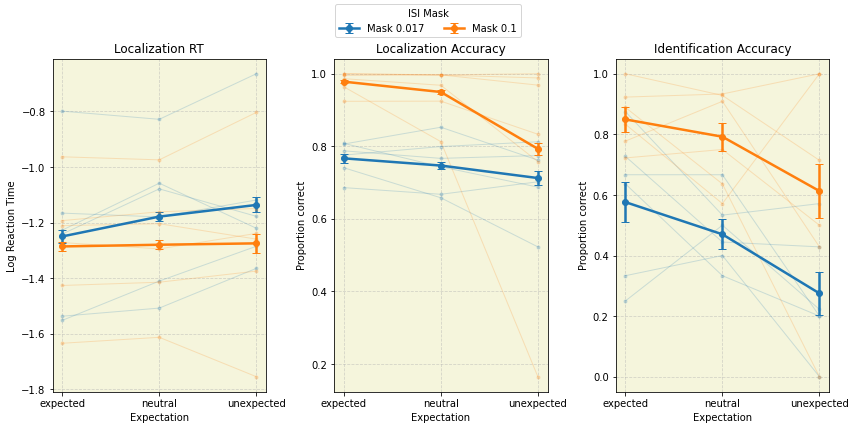

In [5]:
import matplotlib.pyplot as plt

def plot_interaction(ax, df, dv, ylabel):
    expectations = ['expected', 'neutral', 'unexpected']  # fixed order
    masks = sorted(df["isi_mask"].unique())
    colors = ['#1f77b4', '#ff7f0e']  # blue, orange

    x = np.arange(len(expectations))
    lines = []

    for i, mask in enumerate(masks):
        subset = df[df["isi_mask"] == mask]
        color = colors[i]

        # ── individual participant lines (thin, transparent) ──
        for participant in subset["participant"].unique():
            p_data = (
                subset[subset["participant"] == participant]
                .groupby("expectation")[dv]
                .mean()
                .reindex(expectations)
            )
            ax.plot(x, p_data, color=color, alpha=0.2, linewidth=1,
                    marker='o', markersize=3)

        # ── group mean + SEM (thick, solid) ──
        means = subset.groupby("expectation")[dv].mean().reindex(expectations)
        ses   = subset.groupby("expectation")[dv].sem().reindex(expectations)

        line = ax.errorbar(
            x, means, yerr=ses,
            marker="o", capsize=4, linewidth=2.5, markersize=6,
            color=color, label=f"Mask {mask}"
        )
        lines.append(line)

    ax.set_xticks(x)
    ax.set_xticklabels(expectations)
    ax.set_xlabel("Expectation")
    ax.set_ylabel(ylabel)
    ax.patch.set_facecolor("#f5f5dc")

    return lines


fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharex=True)

lines = plot_interaction(axes[0], beh_data, "rt_loc_log", "Log Reaction Time")
axes[0].set_title("Localization RT")
axes[0].grid(linestyle="--", alpha=0.5)

plot_interaction(axes[1], beh_data, "correct_loc", "Proportion correct")
axes[1].set_title("Localization Accuracy")
axes[1].grid(linestyle="--", alpha=0.5)

plot_interaction(axes[2], beh_data[beh_data.identity_catch == True], "correct_id", "Proportion correct")
axes[2].set_title("Identification Accuracy")
axes[2].grid(linestyle="--", alpha=0.5)

labels = [l.get_label() for l in lines]
fig.legend(lines, labels, title="ISI Mask", loc="upper center", ncol=len(labels))

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [66]:
from scipy import stats

# ── Step 1: aggregate to participant means (match what your plots show) ──
cell_means = (
    beh_data
    .groupby(['participant', 'isi_mask', 'expectation'], observed=True)
    .agg(
        rt_loc    = ('rt_loc_log',     'mean'),
        acc_loc   = ('correct_loc','mean'),
        acc_id    = ('correct_id', 'mean'),   # adjust column name if different
    )
    .reset_index()
)

print(cell_means.head(12))
print("\nParticipants:", cell_means['participant'].nunique())
print("Cells per participant:", cell_means.groupby('participant').size().unique())

    participant  isi_mask expectation    rt_loc   acc_loc    acc_id
0             0     0.017    expected -1.551620  0.806283  0.666667
1             0     0.017     neutral -1.410286  0.852632  0.666667
2             0     0.017  unexpected -1.285075  0.761905  0.200000
3             0     0.100    expected -1.426062  1.000000  0.777778
4             0     0.100     neutral -1.414369  0.996479  0.909091
5             0     0.100  unexpected -1.374305  0.988636  0.428571
6             1     0.017    expected -1.536620  0.787500  0.727273
7             1     0.017     neutral -1.507437  0.766764  0.444444
8             1     0.017  unexpected -1.364570  0.774510  0.428571
9             1     0.100    expected -1.633950  1.000000  0.923077
10            1     0.100     neutral -1.612575  0.997085  0.933333
11            1     0.100  unexpected -1.754132  1.000000  1.000000

Participants: 6
Cells per participant: [6]


In [67]:
from statsmodels.stats.anova import AnovaRM

for dv in ['rt_loc', 'acc_loc', 'acc_id']:
    print(f"\n{'='*55}")
    print(f"  rm-ANOVA: {dv}")
    print(f"{'='*55}")
    result = AnovaRM(
        data=cell_means,
        depvar=dv,
        subject='participant',
        within=['isi_mask', 'expectation']
    ).fit()
    print(result.summary())


  rm-ANOVA: rt_loc
                      Anova
                     F Value Num DF  Den DF Pr > F
--------------------------------------------------
isi_mask              6.1780 1.0000  5.0000 0.0555
expectation           2.5290 2.0000 10.0000 0.1292
isi_mask:expectation  1.8319 2.0000 10.0000 0.2100


  rm-ANOVA: acc_loc
                      Anova
                     F Value Num DF  Den DF Pr > F
--------------------------------------------------
isi_mask             25.1387 1.0000  5.0000 0.0041
expectation           2.4420 2.0000 10.0000 0.1369
isi_mask:expectation  2.1394 2.0000 10.0000 0.1685


  rm-ANOVA: acc_id
                      Anova
                     F Value Num DF  Den DF Pr > F
--------------------------------------------------
isi_mask             14.4167 1.0000  5.0000 0.0127
expectation           5.7363 2.0000 10.0000 0.0219
isi_mask:expectation  0.0932 2.0000 10.0000 0.9118



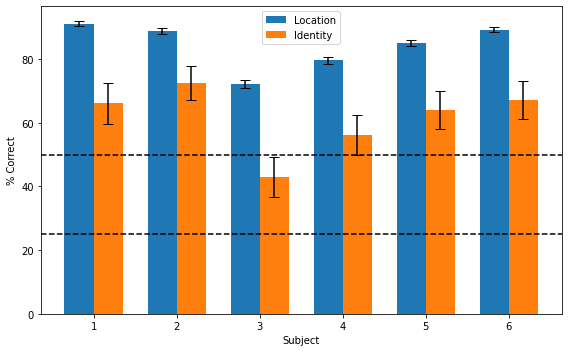

In [60]:
import matplotlib.pyplot as plt

loc_means = []
loc_se = []
id_means = []
id_se = []

for lc, ide in zip(loc, identity):
    # remove NaNs
    lc_valid = lc[~np.isnan(lc)] 
    ide_valid = ide[~np.isnan(ide)]

    loc_means.append(np.mean(lc_valid) * 100)
    id_means.append(np.mean(ide_valid) * 100)

    loc_se.append(np.std(lc_valid, ddof=1) / np.sqrt(len(lc_valid)) * 100)
    id_se.append(np.std(ide_valid, ddof=1) / np.sqrt(len(ide_valid)) * 100)

x = np.arange(len(loc_means))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, loc_means, width, yerr=loc_se, label='Location', capsize=5)
plt.bar(x + width/2, id_means, width, yerr=id_se, label='Identity', capsize=5)

plt.xlabel("Subject")
plt.ylabel("% Correct")
plt.xticks(x, np.arange(1, len(x)+1))  # subjects labeled 1..N
plt.legend()

plt.tight_layout()
plt.axhline(25, color="k", linestyle="--")
plt.axhline(50, color="k", linestyle="--")
plt.show()

### EEG Check


In [70]:
### Needed if you want to plot some MNE plots 
%matplotlib inline 

In [101]:
# Events 
def get_main_events():
    base = np.array([1,2,3,4,5,6,7,8])
    mask_conds = np.append(base + 10, base + 20)
    events = np.append(mask_conds, mask_conds + 100)
    events = np.append(events, mask_conds + 200)
    return events

def condition_events(allowed_events, rename_cond="side"):
    rename_dict = {}

    if rename_cond == "side":
        for event_num in allowed_events:
            base_digit = event_num % 10
            s = str(event_num)
            if base_digit in [1,2,3,4]:
                side = "Left"
            else:
                side = "Right"
            if len(s) <= 2:
                rename_dict[f'Stimulus/S {event_num}'] = side
            else:
                rename_dict[f'Stimulus/S{event_num}'] = side
                

    if rename_cond == "side/mask":
        for event_num in allowed_events:
            base_digit = event_num % 10
            s = str(event_num)
            second_digit = int(s[0]) if len(s) == 2 else int(s[1])
            if base_digit in [1,2,3,4]:
                side = "Left"
            else:
                side = "Right"
            if second_digit == 1:
                mask = "Short"
            else:
                mask = "Long"
            if len(s) <= 2:
                rename_dict[f'Stimulus/S {event_num}'] = f"{side}/{mask}"
            else:
                rename_dict[f'Stimulus/S{event_num}'] = f"{side}/{mask}"
    if rename_cond == "stims":
        for event_num in allowed_events:
            s = str(event_num)
            if len(s) <= 2:
                rename_dict[f'Stimulus/S {event_num}'] = f'Stimulus/S {event_num}'
            else:
                rename_dict[f'Stimulus/S{event_num}'] = f'Stimulus/S{event_num}'
    return rename_dict

In [114]:
import os
import mne
import numpy as np

sub = 2
tmin, tmax = -0.2, 1.0
baseline=(-0.2, 0)

folder_name = f"sub-{sub:04d}"
sub_folder = os.path.join(PATH, "eeg", folder_name)
files = os.listdir(sub_folder)

vhdrs = [x for x in files if ".vhdr" in x]
raw = []
allowed_events = get_main_events()
rename_dict = condition_events(allowed_events=allowed_events)

for vhdr in vhdrs:
    vhdr_file =os.path.join(sub_folder, vhdr)
    raw.append(mne.io.read_raw_brainvision(vhdr_file, preload=True))
    

raw = mne.concatenate_raws(raw)
# Renaming only for condition epoching (Univ.)
raw.annotations.rename(rename_dict)

# Resample to 250 Hz (default)
print('Downsample Raw...')
raw = raw.resample(250)

print("Re-referencing...")
raw, _ = mne.set_eeg_reference(
    raw,
    ref_channels='average',
    copy=True,
    projection=False,
    ch_type='auto',
    forward=None,
    joint=False,
    verbose=None
)
    
# Get events from eeg
events, events_ids = mne.events_from_annotations(raw)
events  = events[2:, :]
condition_keys = list(set(rename_dict.values()))
event_dict = {}
for ck in condition_keys:
    event_dict[ck] = events_ids[ck]

# Extract epochs
epochs = mne.Epochs(
raw,
events,
event_id=event_dict,
tmin=tmin,
tmax=tmax,
baseline=baseline, 
preload=True)

# Set M1 montage 
epochs.set_channel_types({
    'VEOG1': 'eog',
    'VEOG2': 'eog',
    'HEOG1': 'eog',
    'HEOG2': 'eog'
})

montage = mne.channels.make_standard_montage('easycap-M1')
epochs.set_montage(montage)

# compute left and right
left = epochs["Left"].average()
right = epochs["Right"].average()



Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0002/Mask_ExpAtt_00_0002.vhdr...
Setting channel info structure...
Reading 0 ... 1585979  =      0.000 ...  1585.979 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0002/Mask_ExpAtt_01_0002.vhdr...
Setting channel info structure...
Reading 0 ... 1452319  =      0.000 ...  1452.319 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0002/Mask_ExpAtt_02_0002.vhdr...
Setting channel info structure...
Reading 0 ... 1676759  =      0.000 ...  1676.759 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0002/Mask_ExpAtt_03_0002.vhdr...
Setting channel info structure...
Reading 0 ... 1364499  =      0.000 ...  1364.499 secs...
Downsample Raw...
Re-referencing...
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used 

### ERP side only

In [80]:
import os
import mne
import numpy as np

left_all = []
right_all = []

subjects = [0,1,2,3,4,5]
tmin, tmax = -1.2, 1.0
baseline = (-1.2, -1.0)
highpass = 0.1
lowpass = 100


for sub in subjects:

    folder_name = f"sub-{sub:04d}"
    sub_folder = os.path.join(PATH, "eeg", folder_name)
    files = os.listdir(sub_folder)

    vhdrs = [x for x in files if ".vhdr" in x]
    raw = []
    allowed_events = get_main_events()
    rename_dict = condition_events(allowed_events=allowed_events)

    for vhdr in vhdrs:
        vhdr_file = os.path.join(sub_folder, vhdr)
        raw.append(mne.io.read_raw_brainvision(vhdr_file, preload=True))

    raw = mne.concatenate_raws(raw)

    raw.annotations.rename(rename_dict)
    ("Filtering...")
    eeg_picks = mne.pick_types(raw.info, eeg=True)
    
    raw = raw.filter(l_freq=highpass, h_freq=lowpass, picks=eeg_picks)
    raw = raw.resample(250)
    raw.set_channel_types({
        'VEOG1':'eog',
        'VEOG2':'eog',
        'HEOG1':'eog',
        'HEOG2':'eog'
    })
    raw, _ = mne.set_eeg_reference(raw, ref_channels='average')

    events, events_ids = mne.events_from_annotations(raw)
    events = events[2:, :]

    condition_keys = list(set(rename_dict.values()))
    event_dict = {ck: events_ids[ck] for ck in condition_keys}

    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_dict,
        tmin=tmin,
        tmax=tmax,
        baseline=baseline,
        preload=True
    )


    montage = mne.channels.make_standard_montage('easycap-M1')
    epochs.set_montage(montage)

    # subject averages
    left_all.append(epochs["Left"].average())
    right_all.append(epochs["Right"].average())

Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0000/MaskExpatt_00_0000.vhdr...
Setting channel info structure...
Reading 0 ... 928519  =      0.000 ...   928.519 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0000/MaskExpatt_01_0000.vhdr...
Setting channel info structure...
Reading 0 ... 1437719  =      0.000 ...  1437.719 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0000/MaskExpatt_02_0000.vhdr...
Setting channel info structure...
Reading 0 ... 1322359  =      0.000 ...  1322.359 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0000/MaskExpatt_03_0000.vhdr...
Setting channel info structure...
Reading 0 ... 1205659  =      0.000 ...  1205.659 secs...
Filtering raw data in 4 contiguous segments
Setting up band-pass filter from 0.1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    3.5s finished


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Comment/ControlBox is not connected via USB', 'Left', 'New Segment/', 'Right', 'Stimulus/S  1', 'Stimulus/S  5', 'Stimulus/S 99']
Not setting metadata
1173 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1173 events and 551 original time points ...
0 bad epochs dropped
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0001/MaskExpatt_00_0001.vhdr...
Setting channel info structure...
Reading 0 ... 1356679  =      0.000 ...  1356.679 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0001/MaskExpatt_01_0001.vhdr...
Setting channel info structure...
Reading 0 ... 1509659  =      0.000 ...  1509.659 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/su

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    3.9s finished


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Comment/ControlBox is not connected via USB', 'Left', 'New Segment/', 'Right', 'Stimulus/S  1', 'Stimulus/S 99']
Not setting metadata
1280 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1280 events and 551 original time points ...
0 bad epochs dropped
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0002/Mask_ExpAtt_00_0002.vhdr...
Setting channel info structure...
Reading 0 ... 1585979  =      0.000 ...  1585.979 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0002/Mask_ExpAtt_01_0002.vhdr...
Setting channel info structure...
Reading 0 ... 1452319  =      0.000 ...  1452.319 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0002/Mask_Exp

...

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Comment/no USB Connection to actiCAP', 'Left', 'New Segment/', 'Right', 'Stimulus/S  1', 'Stimulus/S 99']
Not setting metadata
1280 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1280 events and 551 original time points ...
0 bad epochs dropped
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0004/Mask_ExpAtt_00_0004.vhdr...
Setting channel info structure...
Reading 0 ... 1407979  =      0.000 ...  1407.979 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0004/Mask_ExpAtt_01_0004.vhdr...
Setting channel info structure...
Reading 0 ... 1460939  =      0.000 ...  1460.939 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0004/Mask_ExpAtt_02_

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    3.5s finished


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Comment/no USB Connection to actiCAP', 'Left', 'New Segment/', 'Right', 'Stimulus/S  1', 'Stimulus/S  5', 'Stimulus/S 99']
Not setting metadata
1280 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1280 events and 551 original time points ...
0 bad epochs dropped
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0005/Mask_ExpAtt_00_0005.vhdr...
Setting channel info structure...
Reading 0 ... 1472979  =      0.000 ...  1472.979 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0005/Mask_ExpAtt_01_0005.vhdr...
Setting channel info structure...
Reading 0 ... 1447939  =      0.000 ...  1447.939 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-000

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    3.5s finished


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Comment/no USB Connection to actiCAP', 'Left', 'New Segment/', 'Right', 'Stimulus/S  1', 'Stimulus/S  5', 'Stimulus/S 99']
Not setting metadata
1280 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1280 events and 551 original time points ...
0 bad epochs dropped


Identifying common channels ...
Identifying common channels ...
combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)


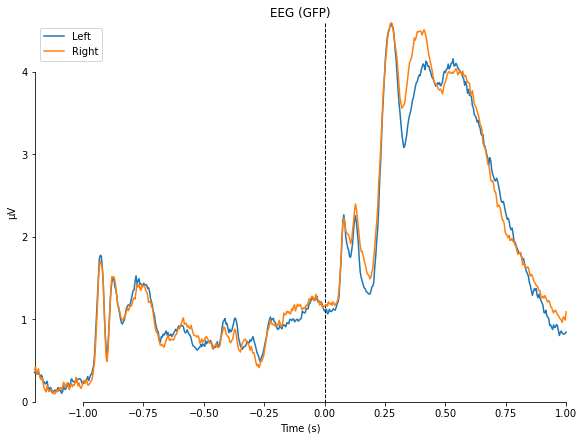

[<Figure size 576x432 with 1 Axes>]

In [81]:
left_grand = mne.grand_average(left_all)
right_grand = mne.grand_average(right_all)

mne.viz.plot_compare_evokeds(
    {"Left": left_grand, "Right": right_grand},
    picks="eeg"
)

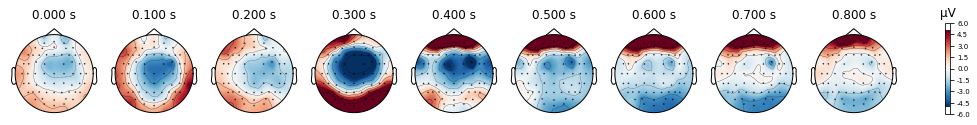

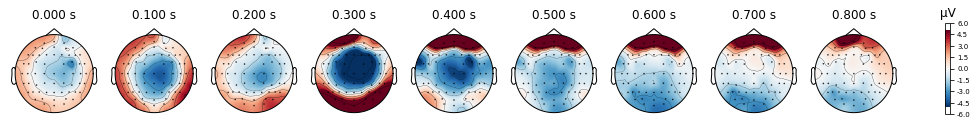

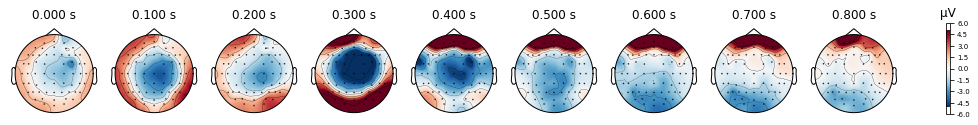

In [82]:
vlim = (-5, 5)

left_grand.plot_topomap(times=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8], vlim=vlim)
right_grand.plot_topomap(times=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8], vlim=vlim)

### ERPs for Mask x Side

In [117]:
import os
import mne
import numpy as np

left_short = []
right_short = []
left_long = []
right_long = []

subjects = [0,1,2,3,4,5]
tmin, tmax = -1.2, 1.0
baseline = (-1.2, -1.0)
highpass = 0.1
lowpass = 100


for sub in subjects:

    folder_name = f"sub-{sub:04d}"
    sub_folder = os.path.join(PATH, "eeg", folder_name)
    files = os.listdir(sub_folder)

    vhdrs = [x for x in files if ".vhdr" in x]
    raw = []
    allowed_events = get_main_events()
    rename_dict = condition_events(allowed_events=allowed_events,  rename_cond="side/mask")

    for vhdr in vhdrs:
        vhdr_file = os.path.join(sub_folder, vhdr)
        raw.append(mne.io.read_raw_brainvision(vhdr_file, preload=True))

    raw = mne.concatenate_raws(raw)

    raw.annotations.rename(rename_dict)
    raw = raw.filter(l_freq=highpass, h_freq=lowpass, picks=eeg_picks)
    raw = raw.resample(250)
    raw.set_channel_types({
    'VEOG1':'eog',
    'VEOG2':'eog',
    'HEOG1':'eog',
    'HEOG2':'eog'
})
    raw, _ = mne.set_eeg_reference(raw, ref_channels='average', ch_type = 'eeg')

    raw, _ = mne.set_eeg_reference(raw, ref_channels='average')

    events, events_ids = mne.events_from_annotations(raw)
    events = events[2:, :]

    condition_keys = list(set(rename_dict.values()))
    event_dict = {ck: events_ids[ck] for ck in condition_keys}

    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_dict,
        tmin=tmin,
        tmax=tmax,
        baseline=baseline,
        preload=True
    )

    montage = mne.channels.make_standard_montage('easycap-M1')
    epochs.set_montage(montage)

    # subject averages
    left_short.append(epochs["Left/Short"].average())
    right_short.append(epochs["Right/Short"].average())
    left_long.append(epochs["Left/Long"].average())
    right_long.append(epochs["Right/Long"].average())

Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0000/MaskExpatt_00_0000.vhdr...
Setting channel info structure...
Reading 0 ... 928519  =      0.000 ...   928.519 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0000/MaskExpatt_01_0000.vhdr...
Setting channel info structure...
Reading 0 ... 1437719  =      0.000 ...  1437.719 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0000/MaskExpatt_02_0000.vhdr...
Setting channel info structure...
Reading 0 ... 1322359  =      0.000 ...  1322.359 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0000/MaskExpatt_03_0000.vhdr...
Setting channel info structure...
Reading 0 ... 1205659  =      0.000 ...  1205.659 secs...
Filtering raw data in 4 contiguous segments
Setting up band-pass filter from 0.1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    3.7s finished


Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Comment/ControlBox is not connected via USB', 'Left/Long', 'Left/Short', 'New Segment/', 'Right/Long', 'Right/Short', 'Stimulus/S  1', 'Stimulus/S  5', 'Stimulus/S 99']
Not setting metadata
1173 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1173 events and 551 original time points ...
0 bad epochs dropped
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0001/MaskExpatt_00_0001.vhdr...
Setting channel info structure...
Reading 0 ... 1356679  =      0.000 ...  1356.679 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0001/MaskExpatt_01_0001.vhdr...
Setting channel info structure...
Reading 0 ... 1509659  =      0.000 ..

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.1s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    4.0s finished


Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Comment/ControlBox is not connected via USB', 'Left/Long', 'Left/Short', 'New Segment/', 'Right/Long', 'Right/Short', 'Stimulus/S  1', 'Stimulus/S 99']
Not setting metadata
1280 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1280 events and 551 original time points ...
0 bad epochs dropped
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0002/Mask_ExpAtt_00_0002.vhdr...
Setting channel info structure...
Reading 0 ... 1585979  =      0.000 ...  1585.979 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0002/Mask_ExpAtt_01_0002.vhdr...
Setting channel info structure...
Reading 0 ... 1452319  =      0.000 ...  1452.319 sec

...

Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Comment/no USB Connection to actiCAP', 'Left/Long', 'Left/Short', 'New Segment/', 'Right/Long', 'Right/Short', 'Stimulus/S  1', 'Stimulus/S 99']
Not setting metadata
1280 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1280 events and 551 original time points ...
0 bad epochs dropped
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0004/Mask_ExpAtt_00_0004.vhdr...
Setting channel info structure...
Reading 0 ... 1407979  =      0.000 ...  1407.979 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0004/Mask_ExpAtt_01_0004.vhdr...
Setting channel info structure...
Reading 0 ... 1460939  =      0.000 ...  1460.939 secs...
Ex

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    3.4s finished


Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Comment/no USB Connection to actiCAP', 'Left/Long', 'Left/Short', 'New Segment/', 'Right/Long', 'Right/Short', 'Stimulus/S  1', 'Stimulus/S  5', 'Stimulus/S 99']
Not setting metadata
1280 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1280 events and 551 original time points ...
0 bad epochs dropped
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0005/Mask_ExpAtt_00_0005.vhdr...
Setting channel info structure...
Reading 0 ... 1472979  =      0.000 ...  1472.979 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0005/Mask_ExpAtt_01_0005.vhdr...
Setting channel info structure...
Reading 0 ... 1447939  =      0.000 ...  14

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    3.5s finished


Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Comment/no USB Connection to actiCAP', 'Left/Long', 'Left/Short', 'New Segment/', 'Right/Long', 'Right/Short', 'Stimulus/S  1', 'Stimulus/S  5', 'Stimulus/S 99']
Not setting metadata
1280 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1280 events and 551 original time points ...
0 bad epochs dropped


Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)


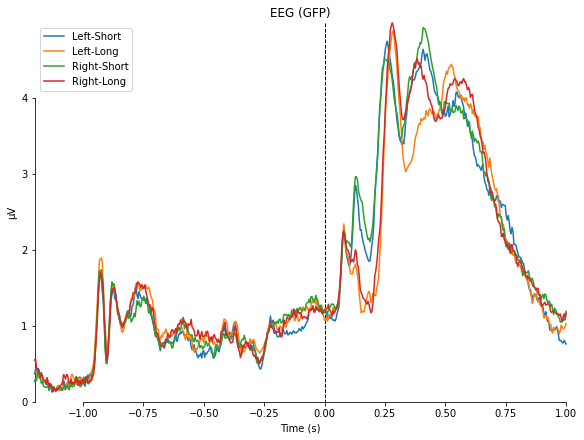

[<Figure size 576x432 with 1 Axes>]

In [118]:
left_short_grand = mne.grand_average(left_short)
right_short_grand = mne.grand_average(right_short)
left_long_grand = mne.grand_average(left_long)
right_long_grand = mne.grand_average(right_long)

mne.viz.plot_compare_evokeds(
    {"Left-Short": left_short_grand, "Left-Long": left_long_grand,
    "Right-Short": right_short_grand, "Right-Long": right_long_grand},
    picks="eeg")
    
    

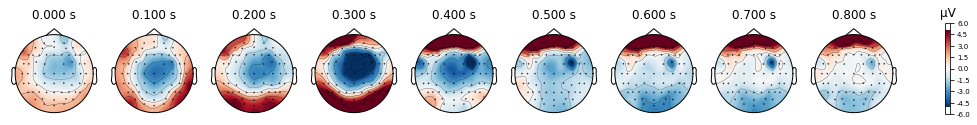

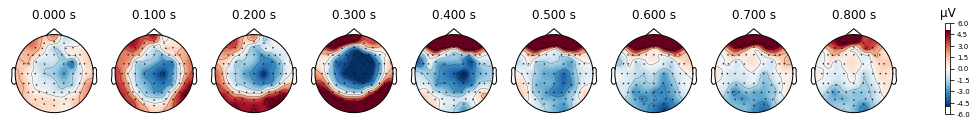

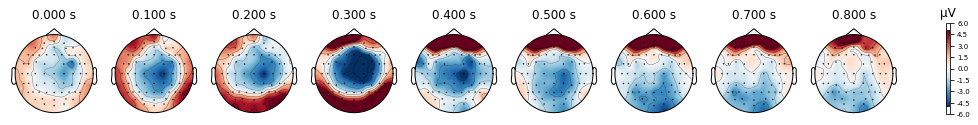

In [119]:
vlim = (-5, 5)

left_short_grand.plot_topomap(times=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8], vlim=vlim)
right_short_grand.plot_topomap(times=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8], vlim=vlim)

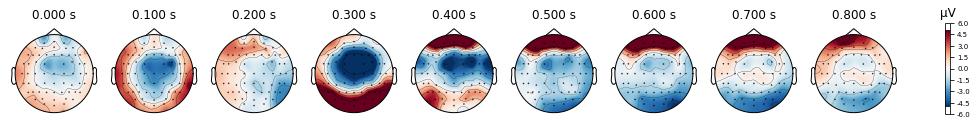

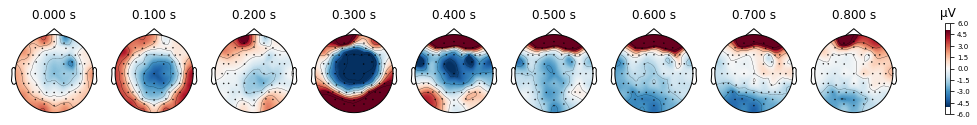

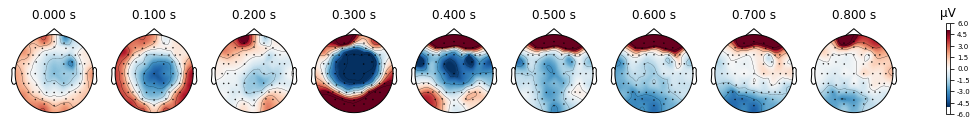

In [87]:
left_long_grand.plot_topomap(times=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8], vlim=vlim)
right_long_grand.plot_topomap(times=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8], vlim=vlim)

In [124]:
### create preprocessing function 

# params
sub = 5
tmin, tmax = -0.2, 1.0
baseline = (-0.2, 0)
highpass = 0.1
lowpass = 100
resample = 250

# load raw files
folder_name = f"sub-{sub:04d}"
sub_folder = os.path.join(PATH, "eeg", folder_name)
files = os.listdir(sub_folder)

vhdrs = [x for x in files if ".vhdr" in x]
raw = []
allowed_events = get_main_events()
rename_dict = condition_events(allowed_events=allowed_events,  rename_cond="stims")

for vhdr in vhdrs:
    vhdr_file = os.path.join(sub_folder, vhdr)
    raw.append(mne.io.read_raw_brainvision(vhdr_file, preload=True))

raw = mne.concatenate_raws(raw)
print(f"Filtering: hp = {highpass}, lp = {lowpass}")
raw = raw.filter(l_freq=highpass, h_freq=lowpass, picks=eeg_picks)
print(f"Resampling data to: {resample} Hz")
raw = raw.resample(resample)
print("Re-referencing...")
raw.set_channel_types({
    'VEOG1':'eog',
    'VEOG2':'eog',
    'HEOG1':'eog',
    'HEOG2':'eog'
})
raw, _ = mne.set_eeg_reference(raw, ref_channels='average', ch_type = 'eeg')

events, events_ids = mne.events_from_annotations(raw)
condition_keys = list(set(rename_dict.values()))
event_dict = {ck: events_ids[ck] for ck in condition_keys}

epochs = mne.Epochs(
    raw,
    events,
    event_id=event_dict,
    tmin=tmin,
    tmax=tmax,
    baseline=baseline,
    preload=True,
    picks = 'eeg'
)

montage = mne.channels.make_standard_montage('easycap-M1')
epochs.set_montage(montage)

# Get data
dat = {"eeg": epochs.get_data(),
        "time": epochs.times,
        "ids": epochs.events[::, 2],
        "channels": epochs.ch_names}

epoch_dir = os.path.join(PATH, "eeg_epoched")
if not os.path.exists(epoch_dir):
    os.makedirs(epoch_dir)

if epochs.get_data().shape[-1] > 301:
    dat_name = os.path.join(epoch_dir, f"eeg_MaskExp_{sub:04d}_cue.pickle")
else:
    dat_name = os.path.join(epoch_dir, f"eeg_MaskExp_{sub:04d}.pickle")
    
print(f"Total accepted trials: {dat['eeg'].shape[0]}")
dump_data(dat, dat_name)




Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0005/Mask_ExpAtt_00_0005.vhdr...
Setting channel info structure...
Reading 0 ... 1472979  =      0.000 ...  1472.979 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0005/Mask_ExpAtt_01_0005.vhdr...
Setting channel info structure...
Reading 0 ... 1447939  =      0.000 ...  1447.939 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0005/Mask_ExpAtt_02_0005.vhdr...
Setting channel info structure...
Reading 0 ... 1270959  =      0.000 ...  1270.959 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0005/Mask_ExpAtt_03_0005.vhdr...
Setting channel info structure...
Reading 0 ... 1263039  =      0.000 ...  1263.039 secs...
Filtering: hp = 0.1, lp = 100
Filtering raw data in 4 contiguous segments
Setting up band-pass filter from 0.1 - 1e+02 Hz

FIR filter parameters
-------

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    3.6s finished


Resampling data to: 250 Hz
Re-referencing...
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Comment/no USB Connection to actiCAP', 'New Segment/', 'Stimulus/S  1', 'Stimulus/S  5', 'Stimulus/S 11', 'Stimulus/S 12', 'Stimulus/S 13', 'Stimulus/S 14', 'Stimulus/S 15', 'Stimulus/S 16', 'Stimulus/S 17', 'Stimulus/S 18', 'Stimulus/S 21', 'Stimulus/S 22', 'Stimulus/S 23', 'Stimulus/S 24', 'Stimulus/S 25', 'Stimulus/S 26', 'Stimulus/S 27', 'Stimulus/S 28', 'Stimulus/S 99', 'Stimulus/S111', 'Stimulus/S112', 'Stimulus/S113', 'Stimulus/S114', 'Stimulus/S115', 'Stimulus/S116', 'Stimulus/S117', 'Stimulus/S118', 'Stimulus/S121', 'Stimulus/S122', 'Stimulus/S123', 'Stimulus/S124', 'Stimulus/S125', 'Stimulus/S126', 'Stimulus/S127', 'Stimulus/S128', 'Stimulus/S211', 'Stimulus/S212', 'Stimulus/S213', 'Stimulus/S214', 'Stimulus/S215', 'Stimulus/S216', 'Stimulus/S217', 'Stimulus/S218', 'Stimulus/S221', 'Stimulus/S222', 'Stimulus/S223', 'Stimulus/S224', 'S

NameError: name 'dump_data' is not defined

In [24]:
from ExpAtt.data_helpers import dump_data
import mne
import numpy as np 
import os

# Events 
def get_main_events():
    base = np.array([1,2,3,4,5,6,7,8])
    mask_conds = np.append(base + 10, base + 20)
    events = np.append(mask_conds, mask_conds + 100)
    events = np.append(events, mask_conds + 200)
    return events

def condition_events(allowed_events, rename_cond="side"):
    valid_conds = {"side", "side/mask", "stims"}
    
    if rename_cond not in valid_conds:
        raise ValueError(f"rename_cond must be one of {valid_conds}, got '{rename_cond}'")

    rename_dict = {}

    for event_num in allowed_events:
        s = str(event_num)
        key = f"Stimulus/S {event_num}" if len(s) <= 2 else f"Stimulus/S{event_num}"

        if rename_cond == "stims":
            rename_dict[key] = key
            continue

        # shared logic
        base_digit = event_num % 10
        side = "Left" if base_digit in [1, 2, 3, 4] else "Right"

        if rename_cond == "side":
            rename_dict[key] = side

        elif rename_cond == "side/mask":
            second_digit = int(s[0]) if len(s) == 2 else int(s[1])
            mask = "Short" if second_digit == 1 else "Long"
            rename_dict[key] = f"{side}/{mask}"

    return rename_dict

def preprocess_eeg(sub, tmin = -.2, tmax = 1.0, baseline = (-.2, 0), highpass = 0.1, lowpass = 100, resample = 250):
    
    # I don't want to see all the output
    mne.set_log_level('error')
    
    # load raw files
    folder_name = f"sub-{sub:04d}"
    sub_folder = os.path.join(PATH, "eeg", folder_name)
    files = os.listdir(sub_folder)

    vhdrs = [x for x in files if ".vhdr" in x]
    raw = []
    allowed_events = get_main_events()
    rename_dict = condition_events(allowed_events=allowed_events,  rename_cond="stims")

    for vhdr in vhdrs:
        vhdr_file = os.path.join(sub_folder, vhdr)
        raw.append(mne.io.read_raw_brainvision(vhdr_file, preload=True))

    raw = mne.concatenate_raws(raw)
    raw.set_channel_types({
        'VEOG1':'eog',
        'VEOG2':'eog',
        'HEOG1':'eog',
        'HEOG2':'eog'
    })
    
    print(f"Filtering: hp = {highpass}, lp = {lowpass}")
    eeg_picks = mne.pick_types(raw.info, eeg=True)
    raw = raw.filter(l_freq=highpass, h_freq=lowpass, picks=eeg_picks)
    print(f"Resampling data to: {resample} Hz")
    raw = raw.resample(resample)
    print("Re-referencing...")

    raw, _ = mne.set_eeg_reference(raw, ref_channels='average', ch_type = 'eeg')

    events, events_ids = mne.events_from_annotations(raw)
    condition_keys = list(set(rename_dict.values()))
    event_dict = {ck: events_ids[ck] for ck in condition_keys}

    print(f"Epoching: between {tmin}s and {tmax}s with a baseline = {baseline}")
    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_dict,
        tmin=tmin,
        tmax=tmax,
        baseline=baseline,
        preload=True,
        picks = 'eeg'
    )

    montage = mne.channels.make_standard_montage('easycap-M1')
    epochs.set_montage(montage)

    # Get data
    dat = {"eeg": epochs.get_data(),
            "time": epochs.times,
            "ids": epochs.events[::, 2],
            "channels": epochs.ch_names}

    epoch_dir = os.path.join(PATH, "eeg_epoched")
    if not os.path.exists(epoch_dir):
        os.makedirs(epoch_dir)

    if epochs.get_data().shape[-1] > 301:
        dat_name = os.path.join(epoch_dir, f"eeg_MaskExp_{sub:04d}_cue.pickle")
    else:
        dat_name = os.path.join(epoch_dir, f"eeg_MaskExp_{sub:04d}.pickle")
        
    print(f"Total accepted trials: {dat['eeg'].shape[0]}")
    dump_data(dat, dat_name)

    

In [25]:
preprocess_eeg(sub=4)

Filtering: hp = 0.1, lp = 100
Resampling data to: 250 Hz
Re-referencing...
Epoching: between -0.2s and 1.0s with a baseline = (-0.2, 0)
Total accepted trials: 1280
